### Import Libraries and Load Dataset

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure plot aesthetics
sns.set_theme(style="whitegrid")

# Load the dataset from the data directory
# Since the notebook lives inside notebooks/, we step back one folder (..) to reach data/
data_path = os.path.join("..", "data", "StudentPerformanceFactors.csv")
df = pd.read_csv(data_path)

# Display the first 5 records
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Structural Inspection & Summary Statistics

In [4]:
# Check dataset dimensions (rows, columns)
print(f"Dataset Shape: {df.shape}\n")

# Check column data types and non-null counts
print("Data Types & Memory Usage:")
df.info()

# Summary statistics for numerical features
df.describe()

Dataset Shape: (6607, 20)

Data Types & Memory Usage:
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence      

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Checking for Missing (Null) Values

In [5]:
# Count missing values per column
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame(
    {"Missing Values": missing_counts, "Percentage (%)": missing_percent}
)
print(missing_df[missing_df["Missing Values"] > 0])

                          Missing Values  Percentage (%)
Teacher_Quality                       78        1.180566
Parental_Education_Level              90        1.362192
Distance_from_Home                    67        1.014076


### Handling Missing Values & Duplicates

In [14]:
# 1. Remove duplicate entries if any exist
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Dropped {initial_rows - len(df)} duplicate records.")

Dropped 0 duplicate records.


In [17]:
# 2. Impute or handle missing values
# For numerical columns: fill with median (robust against outliers)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].median())

# For categorical columns: fill with mode (most frequent value)
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify no nulls remain
print(f"Remaining null values across dataset: {df.isnull().sum().sum()}")

Remaining null values across dataset: 0


C:\Users\PMYLS\AppData\Local\Temp\ipykernel_3528\3795307441.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


### Data Integrity & Boundary Validation

In [18]:
# Validate that target (Exam_Score) and primary predictor (Hours_Studied) make realistic sense
print(
    f"Hours Studied Range: {df['Hours_Studied'].min()} to"
    f" {df['Hours_Studied'].max()}"
)
print(
    f"Exam Score Range:    {df['Exam_Score'].min()} to"
    f" {df['Exam_Score'].max()}"
)

Hours Studied Range: 1 to 44
Exam Score Range:    55 to 101


In [19]:
# Sanity check: Filter out any corrupted entries (e.g., negative hours or scores above 100)
df = df[(df["Hours_Studied"] >= 0) & (df["Hours_Studied"] <= 168)]  # max hrs/week
df = df[(df["Exam_Score"] >= 0) & (df["Exam_Score"] <= 100)]
print(f"Validated clean dataset size: {len(df)} rows")

Validated clean dataset size: 6606 rows


### Visualizing the Key Relationship (The Core Task)

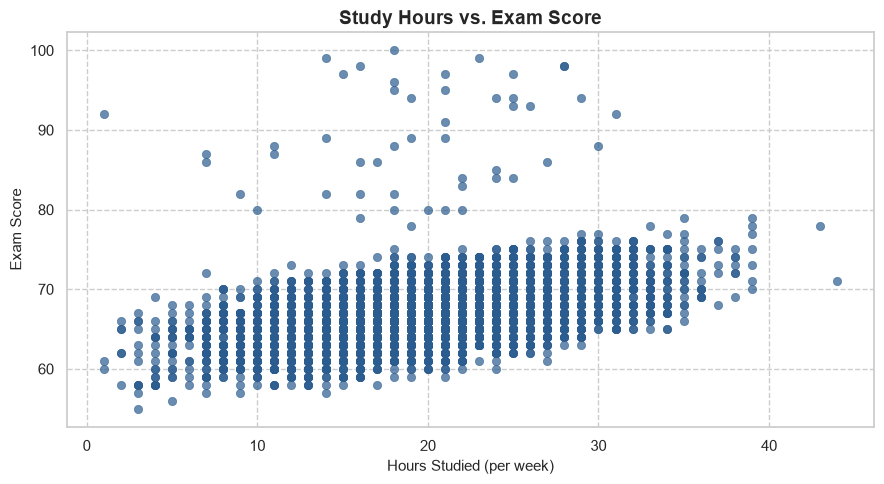

In [34]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score",
    alpha=0.7,
    color="#2b5c8f",
    edgecolor=None,
)

plt.title("Study Hours vs. Exam Score", fontsize=14, weight="bold")
plt.xlabel("Hours Studied (per week)", fontsize=11)
plt.ylabel("Exam Score", fontsize=11)
plt.grid(True, linestyle="--", alpha=1)
plt.tight_layout()
plt.show()

### Feature Correlations (Preparation for Multi-feature Modeling)

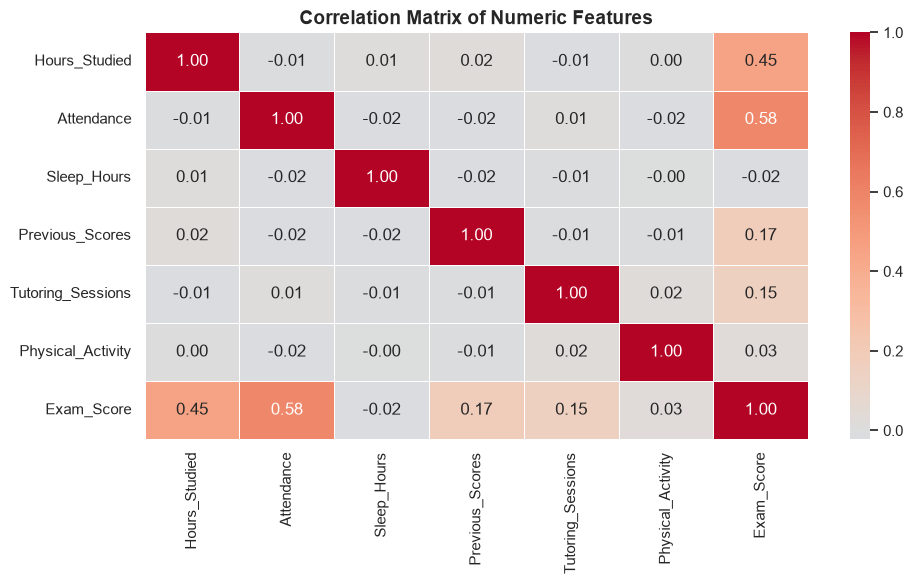

In [35]:
plt.figure(figsize=(10, 6))

# Compute correlation only on numeric columns
numeric_corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    numeric_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Correlation Matrix of Numeric Features", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

### Save Clean Data (Optional but Recommended)

In [36]:
# Save clean data
clean_data_path = os.path.join(
    "..", "data", "cleaned_StudentPerformanceFactors.csv"
)
df.to_csv(clean_data_path, index=False)
print(f"Cleaned dataset saved successfully to {clean_data_path}")

Cleaned dataset saved successfully to ..\data\cleaned_StudentPerformanceFactors.csv


### Splitting the Dataset (Train/Test Split)

### Feature Extraction and Data Splitting

#### Training set ($80\%$): The data the model studies to discover the mathematical relationship between study hours and exam scores.Testing set ($20\%$): Unseen data held back to test whether the model genuinely learned the pattern or merely memorized the training points (overfitting).

In [37]:
from sklearn.model_selection import train_test_split

# 1. Separate independent variable (X) and target variable (y)
# Scikit-learn expects X to be a 2D structure (DataFrame), so we pass a list of column names: [['Hours_Studied']]
X = df[["Hours_Studied"]]
y = df["Exam_Score"]

# 2. Split into 80% train, 20% test
# random_state=42 ensures your split is identical every time you rerun the notebook
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 3. Verify the shapes
print(f"Total samples : {len(df)}")
print(f"Training set  : {X_train.shape[0]} samples")
print(f"Testing set   : {X_test.shape[0]} samples")

Total samples : 6606
Training set  : 5284 samples
Testing set   : 1322 samples


### Model Training (Linear Regression)
#### The brief requires: "Train a linear regression model to estimate final scores."
#### The Math Behind ItA simple linear regression fits the line equation:$$\text{Exam\_Score} = (\text{Slope} \times \text{Hours\_Studied}) + \text{Intercept}$$Slope ($m$ / coef_): How many exam points a student gains on average for each additional hour studied.Intercept ($c$ / intercept_): The expected baseline score if a student studies 0 hours.

### Fitting the Linear Regression Model

In [38]:
from sklearn.linear_model import LinearRegression

# 1. Instantiate the model
linear_model = LinearRegression()

# 2. Train (fit) the model ONLY on the training data
linear_model.fit(X_train, y_train)

# 3. Extract the learned parameters
slope = linear_model.coef_[0]
intercept = linear_model.intercept_

print("Model Training Complete!")
print("-" * 35)
print(f"Slope (Weight / Coefficient) : {slope:.4f}")
print(f"Intercept (Baseline Bias)    : {intercept:.4f}")
print("-" * 35)
print(f"Formula: Exam_Score = ({slope:.2f} * Hours_Studied) + {intercept:.2f}")

Model Training Complete!
-----------------------------------
Slope (Weight / Coefficient) : 0.2857
Intercept (Baseline Bias)    : 61.5460
-----------------------------------
Formula: Exam_Score = (0.29 * Hours_Studied) + 61.55


### Generating Predictions on Unseen Test Data

In [39]:
# Generate predictions on the held-out 20% test dataset
y_pred = linear_model.predict(X_test)

# Compare first 5 actual vs predicted scores side-by-side
comparison_df = pd.DataFrame(
    {
        "Hours Studied": X_test["Hours_Studied"].values[:5],
        "Actual Score": y_test.values[:5],
        "Predicted Score": np.round(y_pred[:5], 2),
        "Residual (Error)": np.round(y_test.values[:5] - y_pred[:5], 2),
    }
)

comparison_df

,Hours Studied,Actual Score,Predicted Score,Residual (Error)
0,16,66,66.12,-0.12
1,15,66,65.83,0.17
2,25,67,68.69,-1.69
3,11,67,64.69,2.31
4,21,68,67.55,0.45


### Model Evaluation & Visualization
### Computing Regression Evaluation Metrics

In [40]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Compute standard regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 2. Display formatted results
print("=" * 40)
print("       LINEAR REGRESSION EVALUATION")
print("=" * 40)
print(f"Mean Absolute Error (MAE)       : {mae:.2f}")
print(f"Mean Squared Error (MSE)        : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE)  : {rmse:.2f}")
print(f"R² Score (Coefficient of Det.)  : {r2:.4f}")
print("=" * 40)

       LINEAR REGRESSION EVALUATION
Mean Absolute Error (MAE)       : 2.42
Mean Squared Error (MSE)        : 9.96
Root Mean Squared Error (RMSE)  : 3.16
R² Score (Coefficient of Det.)  : 0.2469


### Plotting the Regression Line vs. Actual Test Data

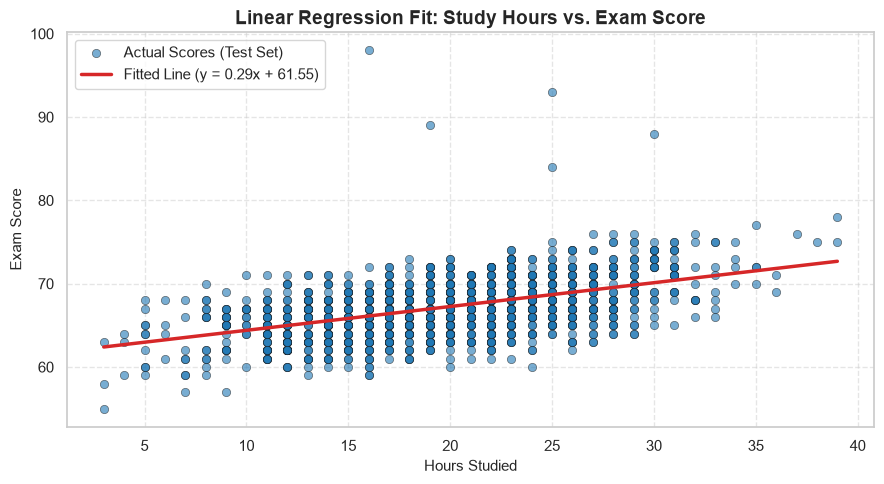

In [42]:
plt.figure(figsize=(9, 5))

# 1. Scatter plot of the held-out test data
plt.scatter(
    X_test,
    y_test,
    color="#1f77b4",
    alpha=0.6,
    edgecolors="k",
    linewidths=0.5,
    label="Actual Scores (Test Set)",
)

# 2. Regression fit line
# Sort X_test values to ensure the line draws cleanly across the domain
sort_idx = np.argsort(X_test["Hours_Studied"].values)
sorted_hours = X_test["Hours_Studied"].values[sort_idx]
sorted_preds = y_pred[sort_idx]

plt.plot(
    sorted_hours,
    sorted_preds,
    color="#d62728",
    linewidth=2.5,
    label=f"Fitted Line (y = {slope:.2f}x + {intercept:.2f})",
)

plt.title(
    "Linear Regression Fit: Study Hours vs. Exam Score",
    fontsize=14,
    weight="bold",
)
plt.xlabel("Hours Studied", fontsize=11)
plt.ylabel("Exam Score", fontsize=11)
plt.legend(frameon=True, facecolor="white", loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Residual Distribution Plot (Diagnostic Check)
#### A model's residuals ($y_{test} - y_{pred}$) should ideally form a bell curve centered at zero:

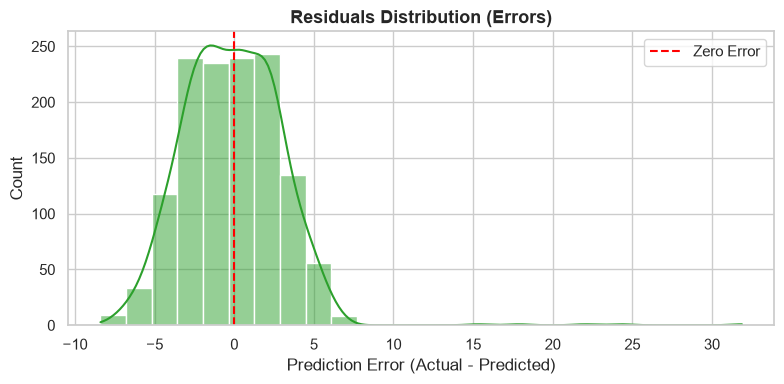

In [43]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color="#2ca02c", bins=25)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero Error")
plt.title("Residuals Distribution (Errors)", fontsize=13, weight="bold")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### Bonus Tasks
##### This phase implements both bonus challenges from the project description:
#### 1. Polynomial Regression: Test whether non-linear curves (e.g., diminishing returns from excess study hours) fit better than a straight line.
#### 2. Multiple Linear Regression: Add features like Sleep_Hours, Attendance, and Tutoring_Sessions to evaluate improvements in predictive power.

### Bonus 1 — Polynomial Regression (Degree 2 and Degree 3)

In [44]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# 1. Degree 2 Polynomial Model (Quadratic)
poly2_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False), LinearRegression()
)
poly2_model.fit(X_train, y_train)
y_pred_poly2 = poly2_model.predict(X_test)

# 2. Degree 3 Polynomial Model (Cubic)
poly3_model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False), LinearRegression()
)
poly3_model.fit(X_train, y_train)
y_pred_poly3 = poly3_model.predict(X_test)

# 3. Compare with Baseline Linear Regression
results_comparison = pd.DataFrame(
    {
        "Model": [
            "Linear Regression (Degree 1)",
            "Polynomial (Degree 2)",
            "Polynomial (Degree 3)",
        ],
        "MAE": [
            mean_absolute_error(y_test, y_pred),
            mean_absolute_error(y_test, y_pred_poly2),
            mean_absolute_error(y_test, y_pred_poly3),
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(y_test, y_pred)),
            np.sqrt(mean_squared_error(y_test, y_pred_poly2)),
            np.sqrt(mean_squared_error(y_test, y_pred_poly3)),
        ],
        "R² Score": [
            r2_score(y_test, y_pred),
            r2_score(y_test, y_pred_poly2),
            r2_score(y_test, y_pred_poly3),
        ],
    }
)

results_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression (Degree 1),2.419018,3.155910,0.246854
1,Polynomial (Degree 2),2.415059,3.153797,0.247862
2,Polynomial (Degree 3),2.417175,3.157678,0.246010


### Visualizing Polynomial Curves vs. Linear Fit

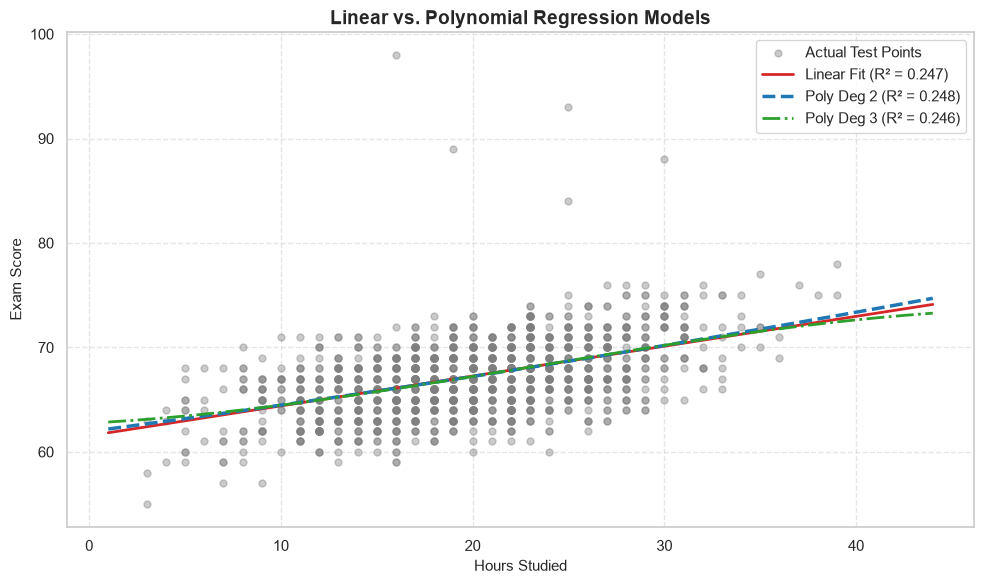

In [45]:
# Generate continuous X values for smooth line plots
x_range = np.linspace(
    X["Hours_Studied"].min(), X["Hours_Studied"].max(), 300
).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range, columns=["Hours_Studied"])

plt.figure(figsize=(10, 6))

# Actual test data points
plt.scatter(
    X_test,
    y_test,
    color="#7f7f7f",
    alpha=0.4,
    label="Actual Test Points",
    s=25,
)

# Linear line
plt.plot(
    x_range,
    linear_model.predict(x_range_df),
    color="#d62728",
    linewidth=2,
    label=f'Linear Fit (R² = {results_comparison.loc[0, "R² Score"]:.3f})',
)

# Polynomial degree 2
plt.plot(
    x_range,
    poly2_model.predict(x_range_df),
    color="#1f77b4",
    linewidth=2.5,
    linestyle="--",
    label=f'Poly Deg 2 (R² = {results_comparison.loc[1, "R² Score"]:.3f})',
)

# Polynomial degree 3
plt.plot(
    x_range,
    poly3_model.predict(x_range_df),
    color="#2ca02c",
    linewidth=2,
    linestyle="-.",
    label=f'Poly Deg 3 (R² = {results_comparison.loc[2, "R² Score"]:.3f})',
)

plt.title(
    "Linear vs. Polynomial Regression Models", fontsize=14, weight="bold"
)
plt.xlabel("Hours Studied", fontsize=11)
plt.ylabel("Exam Score", fontsize=11)
plt.legend(frameon=True, facecolor="white")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Bonus 2 — Multiple Linear Regression (Multi-feature Combinations)

In [46]:
# 1. Select candidate feature sets
candidate_features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Tutoring_Sessions",
]
available_features = [col for col in candidate_features if col in df.columns]

print(f"Features selected for multi-variable regression: {available_features}")

# 2. Create multi-feature split
X_multi = df[available_features]
y_multi = df["Exam_Score"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=42
)

# 3. Train multiple linear regression
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

# 4. Predict and evaluate
y_pred_multi = multi_model.predict(X_test_m)

mae_multi = mean_absolute_error(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))
r2_multi = r2_score(y_test_m, y_pred_multi)

print("\n" + "=" * 45)
print("     MULTIPLE LINEAR REGRESSION RESULTS")
print("=" * 45)
print(f"MAE       : {mae_multi:.2f}")
print(f"RMSE      : {rmse_multi:.2f}")
print(f"R² Score  : {r2_multi:.4f}")
print("-" * 45)

# 5. Inspect individual feature coefficients
coef_summary = pd.DataFrame(
    {"Feature": available_features, "Coefficient (Weight)": multi_model.coef_}
).sort_values(by="Coefficient (Weight)", ascending=False)

print(coef_summary.to_string(index=False))

Features selected for multi-variable regression: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Tutoring_Sessions']

     MULTIPLE LINEAR REGRESSION RESULTS
MAE       : 1.37
RMSE      : 2.15
R² Score  : 0.6500
---------------------------------------------
          Feature  Coefficient (Weight)
Tutoring_Sessions              0.474425
    Hours_Studied              0.290701
       Attendance              0.196570
      Sleep_Hours             -0.022412
